<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_3d_stochastic_dtb_vs_euler_maruyama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D Cournot: stochastic neural-DTB and independent Euler–Maruyama comparison

## Three-player game setup

For player $i$, let $r_i=\sum_{j\ne i}x_j$. With $b=1$ and $\mu=2$, the
payoff-gradient velocity from the thesis is

$$
b_i(x)=-2x_i+4r_i-4r_i^2.
$$

The stochastic dynamics use three independent Brownian motions with the exact
thesis amplitudes

$$
\sigma_1=\sigma_2=\sigma_3=0.1,
\qquad D=\operatorname{diag}(\sigma_1^2,\sigma_2^2,\sigma_3^2)=0.01I_3.
$$

The initial distribution is uniform on $[0,1]^3$, matching the thesis
non-potential experiment. The five reported reference equilibria are the
origin, $(3/8,3/8,3/8)$, and the three permutations of $(1/2,1/2,0)$.
The origin is unstable and the other four are reported as stable. Blocks 0–4 reproduce the existing stochastic neural-DTB experiment.
Blocks 5–8 append an independent Euler–Maruyama experiment and matched snapshots.


Every DTB code cell in Blocks 0–4 is copied verbatim from
[`cournot_3d_nonpotential_stochastic_mlp_dtb.ipynb`](https://github.com/sun-mengwei/dtb-colab-experiments/blob/9792385a49a2c0edc8fd1567f7b1eb86928ab2a3/DTB_Game_Ver2/cournot_3d_nonpotential_stochastic_mlp_dtb.ipynb).
Only this new notebook is added; the original notebook and shared modules are unchanged.
The source revision is `9792385a49a2c0edc8fd1567f7b1eb86928ab2a3`. Repository setup loads shared modules
from the branch in the same way as the original notebook.

Run all cells for both simulations and the matched plots. To run EM alone,
run Blocks 0–2 and 5–6; Block 7 requires the DTB history from Block 3.
The comparison concerns particle distributions at the same times, not identical
sample paths: DTB transports particles with a score-corrected velocity, while
EM adds independent Brownian increments.


## Block 0 — Shared repository setup

This notebook reuses `ResidualMLPMap`, `game_dtb_basis_matrices`, and
`map_at` from `run_game_dtb.py`; `count_trainable` from `network.py`;
and `flat_params` plus `jform_solve` from `dtb.py`. Spatial tangent
derivatives and score evolution come from the shared `utility.py`.

In [1]:
# BLOCK 0 — Locate the shared modules locally or clone the requested branch in Colab.
from pathlib import Path
import math
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

MODULE_FILES = ('run_game_dtb.py', 'network.py', 'dtb.py', 'utility.py')
EXPERIMENT_DIR = next(
    (
        folder
        for folder in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
        if all((folder / name).is_file() for name in MODULE_FILES)
    ),
    None,
)

if EXPERIMENT_DIR is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2 directory.')
    repo = Path('/content/dtb-colab-experiments')
    if not (repo / '.git').exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    else:
        subprocess.run(['git', '-C', str(repo), 'checkout', 'codex/game-dynamics-dtb'], check=True)
        subprocess.run(['git', '-C', str(repo), 'pull', '--ff-only'], check=True)
    EXPERIMENT_DIR = repo / 'DTB_Game_Ver2'

# Import the existing DTB, network, and map primitives requested for reuse.
sys.path.insert(0, str(EXPERIMENT_DIR.resolve()))
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices
from network import count_trainable
from dtb import device, flat_params, jform_solve
from importlib import reload
import utility as stochastic_utility

stochastic_utility = reload(stochastic_utility)
from utility import (
    create_run_directory,
    diagnostics_markdown,
    euler_score_update,
    plot_tangent_diagnostics,
    sample_initial_with_score,
    save_run_data,
    tangent_velocity_spatial_terms,
)

print('Shared module directory:', EXPERIMENT_DIR)

Shared module directory: /content/dtb-colab-experiments/DTB_Game_Ver2


## Block 1 — Game and experiment controls

All numerical, neural-network, stochastic, saving, and visualization
parameters are editable below. The complete realized configuration is
printed after the particles and tangent basis have been initialized.

In [2]:
# BLOCK 1 — Define the three-player game and every editable experiment control.
SAVE_RUN = False  # True creates a uniquely named folder under saved_runs/.
SEED = 2026

DIM = 3
N_PARTICLES = 2000
H = 0.005
T_FINAL = 1.0
N_STEPS = round(T_FINAL / H)
SNAPSHOT_TIMES = (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)

# The paper uses independent noise of amplitude 0.1 in every coordinate.
NOISE_STD = (0.1, 0.1, 0.1)

# "uniform" matches the paper's samples and uses the exact interior score q_0=0.
# "gaussian" and "smoothed_uniform" provide globally smooth analytical scores.
INITIAL_LAW = 'uniform'
GAUSSIAN_MEAN = 0.5
GAUSSIAN_STD = 0.15
UNIFORM_SMOOTHING_STD = 0.02

NN_CHOICE = 'mlp'
NN_ACTIVATION = 'tanh'  # Smooth activation is required by grad(div(u)).
MLP_WIDTH = 32
MLP_DEPTH = 4
BASIS_SIZE = 128
SVD_RTOL = 1e-3
SVD_METHOD = 'svd_gpu'
JACOBIAN_CHUNK = 64
DERIVATIVE_CHUNK = 32
PRINT_EVERY = 20

DTYPE = torch.float32
DEVICE = device()
COURNOT_B = 1.0
COURNOT_MU = 2.0
COORDINATE_PAIRS = ((1, 2),)

def game_velocity(x):
    """Three-player non-potential Cournot payoff-gradient field."""
    if x.shape[-1] != DIM:
        raise ValueError(f'Expected states with last dimension {DIM}.')
    rivals = x.sum(dim=-1, keepdim=True) - x
    return -2.0 * COURNOT_B * x + 2.0 * COURNOT_B * COURNOT_MU * rivals * (1.0 - rivals)

KNOWN_EQUILIBRIA = torch.tensor([
    [0.0, 0.0, 0.0],
    [3/8, 3/8, 3/8],
    [1/2, 1/2, 0.0],
    [1/2, 0.0, 1/2],
    [0.0, 1/2, 1/2],
], device=DEVICE, dtype=DTYPE)
STABLE_MASK = np.array([False, True, True, True, True])

## Block 2 — Particle, score, and neural tangent initialization

The persistent labels start at $x_i^0=X_0(z_i)=z_i$. Each label carries
its score $q_i^0=\nabla\log\rho_0(x_i^0)$. A single seeded subset of MLP
parameter directions defines the tangent basis for the complete run.

In [3]:
# BLOCK 2 — Initialize particles, their scores, and the fixed neural tangent basis.
if NN_ACTIVATION not in {'tanh', 'gelu', 'silu'}:
    raise ValueError('Score evolution requires a twice-differentiable activation.')
if not np.isclose(N_STEPS * H, T_FINAL):
    raise ValueError('T_FINAL must be an integer multiple of H.')
if len(NOISE_STD) != DIM:
    raise ValueError('NOISE_STD needs one independent amplitude per player.')

# Seed the neural network and the initial particle cloud reproducibly.
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
generator_device = DEVICE.type if DEVICE.type == 'cuda' else 'cpu'
initial_generator = torch.Generator(device=generator_device).manual_seed(SEED)

# Attach the analytical initial score to every persistent particle label.
x_0, q_0, log_density_0 = sample_initial_with_score(
    N_PARTICLES,
    DIM,
    law=INITIAL_LAW,
    device=DEVICE,
    dtype=DTYPE,
    generator=initial_generator,
    gaussian_mean=GAUSSIAN_MEAN,
    gaussian_std=GAUSSIAN_STD,
    smoothing_std=UNIFORM_SMOOTHING_STD,
)
x_k = x_0.clone()
q_k = q_0.clone()
log_density_k = log_density_0.clone()

# The fixed MLP provides tangent directions; it is not trained during the run.
mlp = ResidualMLPMap(
    dim=DIM,
    width=MLP_WIDTH,
    depth=MLP_DEPTH,
    activation=NN_ACTIVATION,
    dtype=DTYPE,
    zero_init_output=False,
).net.to(DEVICE)
N_PARAMETERS = count_trainable(mlp)
theta_0, structure, _ = flat_params(mlp)
mlp.requires_grad_(False)

# Select one reproducible random sub-basis and keep it fixed for all time steps.
if not isinstance(BASIS_SIZE, int) or not 1 <= BASIS_SIZE <= N_PARAMETERS:
    raise ValueError(f'BASIS_SIZE must be in [1, {N_PARAMETERS}].')
basis_generator = torch.Generator(device='cpu').manual_seed(SEED)
selected = torch.randperm(N_PARAMETERS, generator=basis_generator)[:BASIS_SIZE]
selected = selected.sort().values.to(DEVICE)

# Sigma is the SDE amplitude; D=Sigma Sigma^T is the Fokker--Planck covariance.
sigma = torch.tensor(NOISE_STD, device=DEVICE, dtype=DTYPE)
diffusion = torch.diag(sigma.square())

# Verify that every plotted analytical reference is stationary for this game field.
equilibrium_residual = float(game_velocity(KNOWN_EQUILIBRIA).norm(dim=1).max())
if equilibrium_residual > 2e-5:
    raise ValueError(f'An equilibrium reference has drift residual {equilibrium_residual:.3e}.')

# Convert requested physical times to exact stored state indices.
snapshot_steps = [round(value / H) for value in SNAPSHOT_TIMES]
if any(not np.isclose(step * H, value) for step, value in zip(snapshot_steps, SNAPSHOT_TIMES)):
    raise ValueError('Every snapshot time must lie on the time grid.')

# Save every experiment setting and the exact selected parameter indices.
CONFIG = {
    'game_dimension': DIM,
    'particles': N_PARTICLES,
    'step_size': H,
    'steps': N_STEPS,
    'final_time': T_FINAL,
    'snapshot_times': list(SNAPSHOT_TIMES),
    'noise_std': list(NOISE_STD),
    'diffusion_diagonal': sigma.square().detach().cpu().tolist(),
    'maximum_equilibrium_residual': equilibrium_residual,
    'initial_law': INITIAL_LAW,
    'gaussian_mean': GAUSSIAN_MEAN,
    'gaussian_std': GAUSSIAN_STD,
    'uniform_smoothing_std': UNIFORM_SMOOTHING_STD,
    'network': NN_CHOICE,
    'activation': NN_ACTIVATION,
    'width': MLP_WIDTH,
    'depth': MLP_DEPTH,
    'trainable_parameters': N_PARAMETERS,
    'basis_size': BASIS_SIZE,
    'selected_parameter_indices': selected.detach().cpu().tolist(),
    'svd_rtol': SVD_RTOL,
    'svd_method': SVD_METHOD,
    'jacobian_chunk': JACOBIAN_CHUNK,
    'derivative_chunk': DERIVATIVE_CHUNK,
    'coordinate_pairs': [list(pair) for pair in COORDINATE_PAIRS],
    'seed': SEED,
    'device': str(DEVICE),
    'dtype': str(DTYPE),
    'save_run': SAVE_RUN,
    'output_root': str(EXPERIMENT_DIR / 'saved_runs'),
}

# Print a complete, readable statement immediately after initialization.
print('=' * 76)
print(f'STOCHASTIC {DIM}D COURNOT NEURAL-DTB EXPERIMENT')
print('=' * 76)
print(f'Game/player dimension: d={DIM}; b={COURNOT_B}; mu={COURNOT_MU}')
print(f'Particles and time: N={N_PARTICLES}; h={H}; K={N_STEPS}; T={T_FINAL}')
print(f'Snapshot times: {SNAPSHOT_TIMES}')
print(f'Noise amplitudes sigma_i: {NOISE_STD}')
print(f'Diffusion covariance diagonal D_ii: {CONFIG["diffusion_diagonal"]}')
print(f'Maximum equilibrium drift residual: {equilibrium_residual:.3e}')
print(f'Initial law: {INITIAL_LAW}; Gaussian mean/std={GAUSSIAN_MEAN}/{GAUSSIAN_STD}; smoothing={UNIFORM_SMOOTHING_STD}')
print(f'Initial score RMS: {float(q_0.square().sum(dim=1).mean().sqrt()):.6g}')
print(f'Network: {NN_CHOICE}; {DIM} -> ' + ' -> '.join([str(MLP_WIDTH)] * MLP_DEPTH) + f' -> {DIM}')
print(f'Activation/depth/width: {NN_ACTIVATION}/{MLP_DEPTH}/{MLP_WIDTH}')
print(f'Trainable parameters: {N_PARAMETERS}')
print(f'Selected tangent size: {BASIS_SIZE}; selection seed={SEED}')
print(f'Selected flat-parameter indices: {CONFIG["selected_parameter_indices"]}')
print(f'Projection solver: {SVD_METHOD}; relative SVD tolerance={SVD_RTOL}')
print(f'Jacobian/derivative chunks: {JACOBIAN_CHUNK}/{DERIVATIVE_CHUNK}')
print(f'Device/dtype: {DEVICE}/{DTYPE}')
print(f'Coordinate planes: {COORDINATE_PAIRS}')
print(f'Save run: {SAVE_RUN}; output root={CONFIG["output_root"]}')
print('Reported reference equilibria:')
for index, point in enumerate(KNOWN_EQUILIBRIA.detach().cpu().numpy()):
    stability = 'stable' if STABLE_MASK[index] else 'unstable'
    print(f'  E_{index} = {np.array2string(point, precision=8)} [{stability}]')
if INITIAL_LAW == 'uniform':
    print('Uniform-score note: q_0=0 is the exact interior score; the boundary score is singular.')
print('=' * 76)

STOCHASTIC 3D COURNOT NEURAL-DTB EXPERIMENT
Game/player dimension: d=3; b=1.0; mu=2.0
Particles and time: N=2000; h=0.005; K=200; T=1.0
Snapshot times: (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)
Noise amplitudes sigma_i: (0.1, 0.1, 0.1)
Diffusion covariance diagonal D_ii: [0.010000000707805157, 0.010000000707805157, 0.010000000707805157]
Maximum equilibrium drift residual: 0.000e+00
Initial law: uniform; Gaussian mean/std=0.5/0.15; smoothing=0.02
Initial score RMS: 0
Network: mlp; 3 -> 32 -> 32 -> 32 -> 32 -> 3
Activation/depth/width: tanh/4/32
Trainable parameters: 3395
Selected tangent size: 128; selection seed=2026
Selected flat-parameter indices: [6, 33, 35, 43, 60, 77, 99, 107, 174, 178, 182, 223, 228, 245, 251, 304, 360, 370, 374, 383, 386, 412, 428, 441, 590, 602, 632, 647, 699, 702, 719, 721, 741, 827, 852, 863, 932, 963, 1032, 1056, 1064, 1101, 1135, 1166, 1237, 1269, 1290, 1310, 1321, 1361, 1397, 1404, 1417, 1556, 1625, 1633, 1652, 1657, 1679, 1682, 1688, 1713, 1714, 1719, 1728, 1750, 17

## Block 3 — Stochastic DTB tangent and score update

At step $k$, the Fokker--Planck transport target is

$$
g_{k,i}=b(x_{k,i})-\frac12Dq_{k,i}.
$$

The selected neural tangent basis is projected onto this target:

$$
\alpha_k=\arg\min_\alpha\sum_i\|J_{k,i}^S\alpha-g_{k,i}\|_2^2,
\qquad u_k(x)=\partial_{\theta_S}f_{\theta_0}(x)\alpha_k.
$$

Particles and attached scores use the same old-step velocity:

$$
x_i^{k+1}=x_i^k+h u_k(x_i^k),
$$

$$
q_i^{k+1}=q_i^k-h\left([D_xu_k(x_i^k)]^\mathsf{T}q_i^k
+\nabla_x[\nabla_x\!\cdot u_k](x_i^k)\right).
$$

This is the ordinary fixed-basis DTB update: there is no resampling, refit,
score network, or post-run polish step.

In [4]:
# BLOCK 3 — Evolve only the stochastic DTB particles and attached scores.
state_times = np.arange(N_STEPS + 1, dtype=float) * H
solve_times = np.arange(N_STEPS, dtype=float) * H

# Histories are copied to CPU after each step to keep GPU memory bounded.
dtb_history = [x_k.detach().cpu().numpy()]
score_history = [q_k.detach().cpu().numpy()]
log_density_history = [log_density_k.detach().cpu().numpy()]
coefficient_history = []
diagnostic_records = []

run_start = time.perf_counter()
for step in range(N_STEPS):
    step_start = time.perf_counter()

    # 1. Evaluate the game drift and score-dependent diffusion correction.
    drift_k = game_velocity(x_k)
    diffusion_correction = 0.5 * (q_k @ diffusion.T)
    target_k = drift_k - diffusion_correction

    # 2. Build the selected neural tangent basis at the current physical particles.
    _, jacobian_tensor, stacked_jacobian = game_dtb_basis_matrices(
        theta_0,
        selected,
        x_k,
        mlp,
        structure,
        chunk=JACOBIAN_CHUNK,
    )

    # 3. Project the stochastic target velocity using the shared DTB SVD solver.
    alpha_k = jform_solve(
        stacked_jacobian,
        target_k.reshape(-1),
        rtol=SVD_RTOL,
        method=SVD_METHOD,
    )

    # 4. Differentiate only the final projected direction u_k=J_k alpha_k.
    tangent_k, grad_u_k, divergence_k, grad_divergence_k = tangent_velocity_spatial_terms(
        theta_0,
        selected,
        alpha_k,
        x_k,
        mlp,
        structure,
        chunk_size=DERIVATIVE_CHUNK,
    )

    # 5. Measure the tangent projection before changing particles or scores.
    residual_k = tangent_k - target_k
    target_norm = target_k.norm().clamp_min(1e-30)
    relative_error = residual_k.norm() / target_norm
    particle_scale = math.sqrt(N_PARTICLES)

    # 6. Update the score with (D_x u_k)^T q_k and grad(div(u_k)).
    q_next, transported_score, score_source = euler_score_update(
        q_k,
        grad_u_k,
        grad_divergence_k,
        H,
    )

    # 7. Apply the ordinary DTB particle-map Euler step using the same old u_k.
    x_next = x_k + H * tangent_k
    log_density_next = log_density_k - H * divergence_k

    # 8. Record the requested tangent metrics and score/diffusion health values.
    diagnostic_records.append({
        'time': step * H,
        'relative_projection_error': float(relative_error),
        'alpha_norm': float(alpha_k.norm()),
        'score_rms': float(q_k.norm() / particle_scale),
        'diffusion_rms': float(diffusion_correction.norm() / particle_scale),
        'target_rms': float(target_k.norm() / particle_scale),
        'tangent_rms': float(tangent_k.norm() / particle_scale),
        'score_transport_rms': float(transported_score.norm() / particle_scale),
        'score_source_rms': float(score_source.norm() / particle_scale),
        'seconds': time.perf_counter() - step_start,
    })
    coefficient_history.append(alpha_k.detach().cpu().numpy())

    # 9. Detach the new state because no gradient graph is propagated across time.
    x_k = x_next.detach()
    q_k = q_next.detach()
    log_density_k = log_density_next.detach()

    # 10. Store full histories so any requested time can be visualized afterward.
    dtb_history.append(x_k.cpu().numpy())
    score_history.append(q_k.cpu().numpy())
    log_density_history.append(log_density_k.cpu().numpy())

    # 11. Fail immediately and identify any non-finite DTB component.
    dtb_states = {
        'particles': x_k,
        'score': q_k,
        'log_density': log_density_k,
    }
    nonfinite_states = [
        name for name, value in dtb_states.items() if not bool(torch.isfinite(value).all())
    ]
    if nonfinite_states:
        raise FloatingPointError(
            f'Non-finite DTB state after step {step + 1}: {nonfinite_states}.'
        )
    if (step + 1) % PRINT_EVERY == 0 or step in (0, N_STEPS - 1):
        record = diagnostic_records[-1]
        print(
            f'k={step + 1:4d}/{N_STEPS}  t={(step + 1) * H:.4f}  '
            f'rel.err={record["relative_projection_error"]:.3e}  '
            f'||alpha||={record["alpha_norm"]:.3e}  '
            f'score.rms={record["score_rms"]:.3e}'
        )

dtb_history = np.stack(dtb_history)
score_history = np.stack(score_history)
log_density_history = np.stack(log_density_history)
coefficient_history = np.stack(coefficient_history)
CONFIG['wall_seconds'] = time.perf_counter() - run_start
print(f'Completed {N_STEPS} stochastic DTB steps in {CONFIG["wall_seconds"]:.2f} seconds.')

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


k=   1/200  t=0.0050  rel.err=4.630e-02  ||alpha||=1.993e+03  score.rms=0.000e+00
k=  20/200  t=0.1000  rel.err=1.983e-01  ||alpha||=1.075e+03  score.rms=6.039e-01
k=  40/200  t=0.2000  rel.err=2.122e-01  ||alpha||=7.492e+02  score.rms=2.076e+00
k=  60/200  t=0.3000  rel.err=3.346e-01  ||alpha||=5.609e+02  score.rms=3.809e+00
k=  80/200  t=0.4000  rel.err=3.660e-01  ||alpha||=7.113e+02  score.rms=5.923e+00
k= 100/200  t=0.5000  rel.err=3.287e-01  ||alpha||=9.407e+02  score.rms=8.608e+00
k= 120/200  t=0.6000  rel.err=3.336e-01  ||alpha||=1.047e+03  score.rms=1.142e+01
k= 140/200  t=0.7000  rel.err=6.224e-01  ||alpha||=3.727e+02  score.rms=1.483e+01
k= 160/200  t=0.8000  rel.err=6.400e-01  ||alpha||=2.510e+02  score.rms=1.797e+01
k= 180/200  t=0.9000  rel.err=6.403e-01  ||alpha||=2.402e+02  score.rms=2.256e+01
k= 200/200  t=1.0000  rel.err=6.726e-01  ||alpha||=1.915e+02  score.rms=2.867e+01
Completed 200 stochastic DTB steps in 350.18 seconds.


## Block 4 — DTB snapshots and diagnostics

The snapshot columns show the neural-DTB particles at the requested
physical times with shared axis limits. The tangent figure shows the
relative projection error and $\|\alpha_k\|_2$ across time. No PCA
is used.

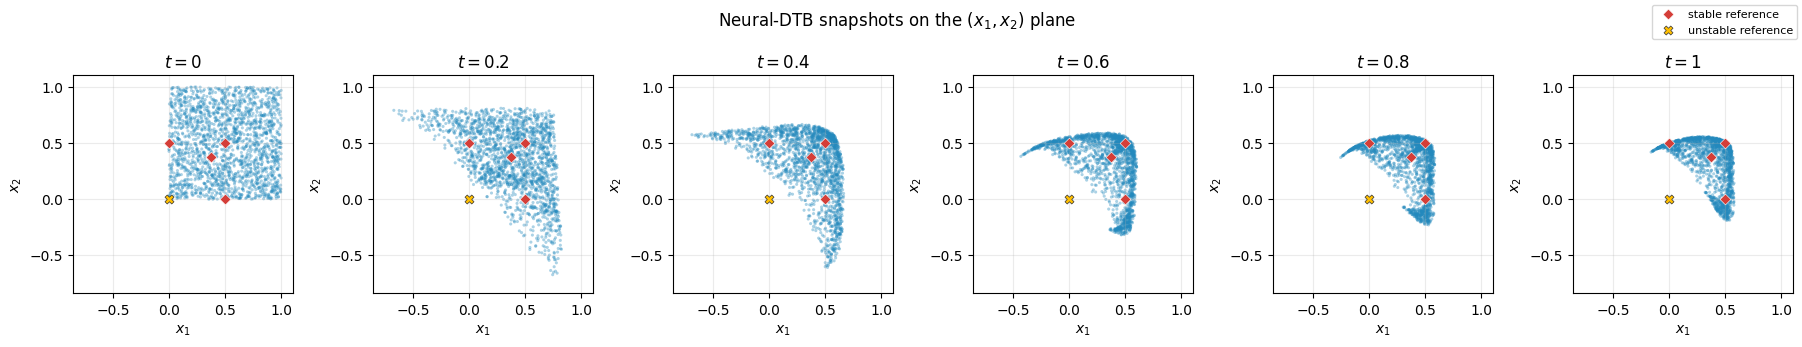

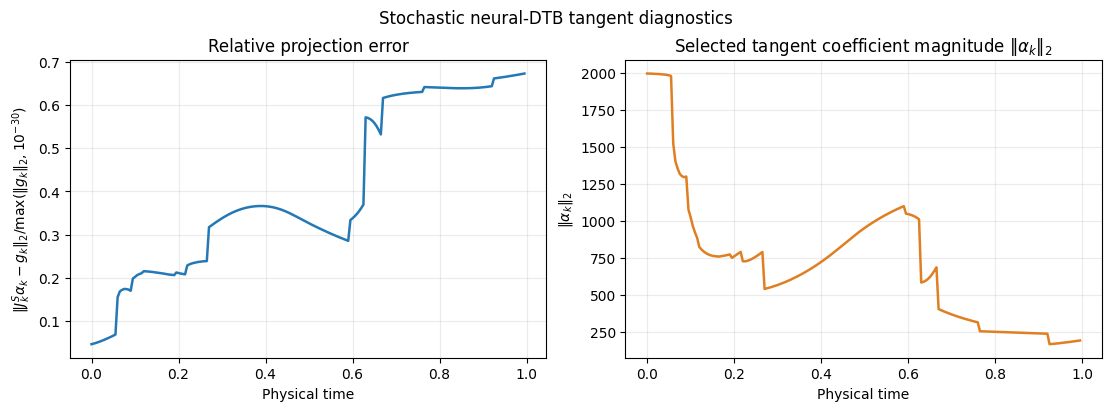

## Stochastic DTB diagnostics

| Metric | Mathematical definition | First | Mean | Final |
| :--- | :--- | ---: | ---: | ---: |
| Relative projection error | $r_k=\frac{\|J_k^S\alpha_k-g_k\|_2}{\max(\|g_k\|_2,10^{-30})}$ | 4.6297e-02 | 4.0303e-01 | 6.7262e-01 |
| Coefficient magnitude | $a_k=\|\alpha_k\|_2$ | 1.9931e+03 | 7.1370e+02 | 1.9146e+02 |
| Score RMS | $s_k=\sqrt{N^{-1}\sum_i\|q_i^k\|_2^2}$ | 0.0000e+00 | 1.0246e+01 | 2.8670e+01 |
| Diffusion correction RMS | $c_k=\frac{1}{2\sqrt N}\|Dq_k\|_2$ | 0.0000e+00 | 5.1229e-02 | 1.4335e-01 |
| Target velocity RMS | $v_k^g=N^{-1/2}\|g_k\|_2$ | 4.2830e+00 | 7.5497e-01 | 2.3463e-01 |
| Tangent velocity RMS | $v_k^u=N^{-1/2}\|u_k\|_2$ | 4.2784e+00 | 7.1003e-01 | 1.7363e-01 |

SAVE_RUN=False: results were displayed without creating an output folder.


In [5]:
# BLOCK 4 — Plot DTB snapshots and tangent diagnostics, then optionally save.
output_dir = None
if SAVE_RUN:
    output_dir = create_run_directory(
        EXPERIMENT_DIR / 'saved_runs',
        dim=DIM,
        network=NN_CHOICE,
        activation=NN_ACTIVATION,
        width=MLP_WIDTH,
        depth=MLP_DEPTH,
        parameter_count=N_PARAMETERS,
        basis_size=BASIS_SIZE,
        seed=SEED,
    )
    CONFIG['output_dir'] = str(output_dir)

# Plot only the DTB cloud, using common limits across every requested time.
def finite_plot_limits(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return (-1.0, 1.0)
    low, high = float(values.min()), float(values.max())
    padding = 0.06 * max(high - low, 1e-3)
    return low - padding, high + padding

snapshot_figures = {}
references = KNOWN_EQUILIBRIA.detach().cpu().numpy()
for first, second in COORDINATE_PAIRS:
    if first == second or not (1 <= first <= DIM and 1 <= second <= DIM):
        raise ValueError('Coordinate pairs use distinct one-based indices.')
    a, b = first - 1, second - 1
    xlim = finite_plot_limits(np.concatenate((dtb_history[:, :, a].ravel(), references[:, a])))
    ylim = finite_plot_limits(np.concatenate((dtb_history[:, :, b].ravel(), references[:, b])))
    figure, axes = plt.subplots(
        1,
        len(snapshot_steps),
        squeeze=False,
        figsize=(3.0 * len(snapshot_steps), 3.4),
        constrained_layout=True,
    )
    for column, snapshot_step in enumerate(snapshot_steps):
        axis = axes[0, column]
        axis.scatter(
            dtb_history[snapshot_step, :, a],
            dtb_history[snapshot_step, :, b],
            s=5, alpha=0.38, color='#2389bd', edgecolors='none', rasterized=True,
        )
        if np.any(STABLE_MASK):
            axis.scatter(
                references[STABLE_MASK, a], references[STABLE_MASK, b],
                s=30, color='#d43e38', marker='D', edgecolors='white',
                linewidths=0.4, label='stable reference', zorder=4,
            )
        if np.any(~STABLE_MASK):
            axis.scatter(
                references[~STABLE_MASK, a], references[~STABLE_MASK, b],
                s=42, color='#ffbf00', marker='X', edgecolors='#333333',
                linewidths=0.5, label='unstable reference', zorder=4,
            )
        axis.set(
            xlim=xlim, ylim=ylim, xlabel=rf'$x_{{{first}}}$',
            ylabel=rf'$x_{{{second}}}$', title=rf'$t={state_times[snapshot_step]:.3g}$',
        )
        axis.set_aspect('equal', adjustable='box')
        axis.grid(alpha=0.25)
    handles, labels = axes[0, -1].get_legend_handles_labels()
    if handles:
        figure.legend(handles, labels, loc='upper right', fontsize=8)
    figure.suptitle(rf'Neural-DTB snapshots on the $(x_{{{first}}},x_{{{second}}})$ plane')
    if output_dir is not None:
        figure.savefig(
            output_dir / f'dtb_snapshots_x{first}_x{second}.png',
            dpi=180, bbox_inches='tight',
        )
    snapshot_figures[(first, second)] = figure

# Plot exactly the two requested tangent-bundle diagnostics against physical time.
relative_projection_errors = np.asarray([
    record['relative_projection_error'] for record in diagnostic_records
])
alpha_norms = np.asarray([record['alpha_norm'] for record in diagnostic_records])
diagnostics_figure = plot_tangent_diagnostics(
    solve_times,
    relative_projection_errors,
    alpha_norms,
    output_path=None if output_dir is None else output_dir / 'tangent_diagnostics.png',
)
plt.show()

# Display the diagnostic definitions and their first, mean, and final values in math.
metric_table = diagnostics_markdown(diagnostic_records)
display(Markdown('## Stochastic DTB diagnostics'))
display(Markdown(metric_table))

# SAVE_RUN=False leaves the repository unchanged and only displays results.
if output_dir is not None:
    save_run_data(
        output_dir,
        config=CONFIG,
        arrays={
            'times': state_times,
            'solve_times': solve_times,
            'dtb_particles': dtb_history,
            'scores': score_history,
            'log_density': log_density_history,
            'coefficients': coefficient_history,
            'selected_parameter_indices': selected.detach().cpu().numpy(),
            'relative_projection_error': relative_projection_errors,
            'alpha_norm': alpha_norms,
        },
        metrics_markdown=metric_table,
    )
    print('Saved figures, histories, configuration, and metric tables to:', output_dir)
else:
    print('SAVE_RUN=False: results were displayed without creating an output folder.')

## Block 5 — Independent EM controls

EM uses the same initial cloud `x_0`, game drift, sample size, step size `H`,
final time, noise amplitudes, device and dtype as DTB. A dedicated generator is
reset whenever Block 6 runs, so rerunning it reproduces the same EM trajectory
in the same runtime. A seed alone does not guarantee identical CPU/GPU samples.

`COMPARISON_VIEW` sets a common two-coordinate plotting window. Panel annotations
count particles outside that window; it does not alter either simulation.
Set it to `None` to display the full coordinate ranges of available snapshots.

In [6]:
EM_SEED = SEED + 10_000
EM_PRINT_EVERY = 10
COMPARISON_VIEW = (-1.0, 1.0)

## Block 6 — Direct Euler–Maruyama simulation

For each particle, with independent standard normal vectors $\xi_k$,

$$X_{k+1}=X_k+H\,b(X_k)+\sqrt{H}\,\Sigma\xi_k,
\qquad \Sigma=\operatorname{diag}(\texttt{NOISE\_STD}).$$

Here `sigma` contains noise **amplitudes**, whereas `diffusion` in DTB is
$D=\Sigma\Sigma^{\mathsf T}$. EM uses `game_velocity` directly and has no score
correction. No boundary projection, reflection, clipping, or taming is applied.

This block owns its state and random generator. On a non-finite proposal it
records the actual failure step and proposal, retains the finite history, and
returns normally so the plots can be inspected. The status explicitly distinguishes
completion through `T_FINAL` from early stopping. No failure time is assumed.

In [7]:
@torch.no_grad()
def simulate_euler_maruyama(initial, drift, noise_std, step_size, steps, seed, print_every=10):
    if initial.ndim != 2 or initial.shape[0] == 0 or not bool(torch.isfinite(initial).all()):
        raise ValueError('initial must be a nonempty finite (particles, dimension) tensor.')
    if not math.isfinite(step_size) or step_size <= 0 or steps < 1 or print_every < 1:
        raise ValueError('step_size, steps, and print_every must be positive.')
    current = initial.detach().clone()
    amplitude = torch.as_tensor(noise_std, device=current.device, dtype=current.dtype)
    if amplitude.shape != (current.shape[1],) or not bool(torch.isfinite(amplitude).all()):
        raise ValueError('noise_std must have one finite amplitude per coordinate.')
    generator = torch.Generator(device=current.device).manual_seed(seed)

    def sync():
        if current.device.type == 'cuda':
            torch.cuda.synchronize(current.device)

    def health(values):
        finite = torch.isfinite(values)
        complete = bool(finite.all())
        return {
            'finite_particles': int(finite.all(dim=1).sum()),
            'nonfinite_components': values.numel() - int(finite.sum()),
            'max_abs': float(values.abs().max()) if complete else float('inf'),
            'coordinate_rms': float(values.double().square().mean().sqrt()) if complete else float('nan'),
        }

    history = [current.cpu().numpy().copy()]
    records = [{'step': 0, 'time': 0.0, **health(current), 'seconds': 0.0, 'elapsed_seconds': 0.0}]
    failure_step = None
    failure_proposal = None
    failed_indices = []
    sync()
    start = time.perf_counter()
    print(f'EM start: N={current.shape[0]}, h={step_size}, K={steps}, '
          f'device={current.device}, dtype={current.dtype}, seed={seed}', flush=True)
    for step in range(1, steps + 1):
        step_start = time.perf_counter()
        noise = torch.randn(current.shape, device=current.device, dtype=current.dtype, generator=generator)
        proposal = current + step_size * drift(current) + math.sqrt(step_size) * amplitude * noise
        values = health(proposal)
        complete = values['nonfinite_components'] == 0
        if complete:
            current = proposal
            history.append(current.cpu().numpy().copy())
        else:
            failure_step = step
            failure_proposal = proposal.cpu().numpy().copy()
            failed_indices = torch.where(~torch.isfinite(proposal).all(dim=1))[0].cpu().tolist()
        sync()
        now = time.perf_counter()
        record = {'step': step, 'time': step * step_size, **values,
                  'seconds': now - step_start, 'elapsed_seconds': now - start}
        records.append(record)
        if step == 1 or step % print_every == 0 or step == steps or not complete:
            eta = (now - start) / step * (steps - step)
            print(f'EM {step:4d}/{steps} t={step * step_size:.4f} '
                  f'finite={values["finite_particles"]}/{current.shape[0]} '
                  f'max|x|={values["max_abs"]:.3e} step={record["seconds"]:.3f}s '
                  f'elapsed={now-start:.2f}s ETA={eta:.2f}s', flush=True)
        if not complete:
            break

    summary = {
        'completed': failure_step is None,
        'completed_finite_steps': len(history) - 1,
        'requested_steps': steps,
        'last_finite_time': (len(history) - 1) * step_size,
        'failure_step': failure_step,
        'failure_time': None if failure_step is None else failure_step * step_size,
        'failed_particle_indices': failed_indices,
        'wall_seconds': time.perf_counter() - start,
        'seed': seed, 'step_size': step_size,
        'noise_std': amplitude.cpu().tolist(),
        'device': str(initial.device), 'dtype': str(initial.dtype),
        'torch_version': str(torch.__version__),
    }
    if summary['completed']:
        print(f'EM COMPLETED: {steps}/{steps} steps, t={steps * step_size:g}.', flush=True)
    else:
        print(f'EM STOPPED EARLY: first non-finite proposal at step {failure_step}, '
              f't={summary["failure_time"]:g}; stored through t={summary["last_finite_time"]:g}.', flush=True)
        print(f'Failed particle indices (first 20): {failed_indices[:20]}', flush=True)
    return {
        'particles': np.stack(history),
        'times': np.arange(len(history), dtype=float) * step_size,
        'records': records, 'summary': summary, 'failure_proposal': failure_proposal,
    }

em_result = simulate_euler_maruyama(
    x_0, game_velocity, NOISE_STD, H, N_STEPS, EM_SEED, EM_PRINT_EVERY,
)
em_history = em_result['particles']
em_times = em_result['times']
em_records = em_result['records']
em_summary = em_result['summary']

EM start: N=2000, h=0.005, K=200, device=cuda:0, dtype=torch.float32, seed=12026
EM    1/200 t=0.0050 finite=2000/2000 max|x|=1.000e+00 step=0.010s elapsed=0.01s ETA=2.02s
EM   10/200 t=0.0500 finite=2000/2000 max|x|=9.941e-01 step=0.001s elapsed=0.02s ETA=0.34s
EM   20/200 t=0.1000 finite=2000/2000 max|x|=9.667e-01 step=0.001s elapsed=0.03s ETA=0.23s
EM   30/200 t=0.1500 finite=2000/2000 max|x|=9.333e-01 step=0.001s elapsed=0.03s ETA=0.19s
EM   40/200 t=0.2000 finite=2000/2000 max|x|=9.043e-01 step=0.001s elapsed=0.04s ETA=0.16s
EM   50/200 t=0.2500 finite=2000/2000 max|x|=8.762e-01 step=0.001s elapsed=0.05s ETA=0.15s
EM   60/200 t=0.3000 finite=2000/2000 max|x|=8.759e-01 step=0.001s elapsed=0.06s ETA=0.13s
EM   70/200 t=0.3500 finite=2000/2000 max|x|=8.636e-01 step=0.001s elapsed=0.07s ETA=0.12s
EM   80/200 t=0.4000 finite=2000/2000 max|x|=7.807e-01 step=0.001s elapsed=0.07s ETA=0.11s
EM   90/200 t=0.4500 finite=2000/2000 max|x|=7.654e-01 step=0.001s elapsed=0.08s ETA=0.10s
EM  100/2

## Block 7 — Matched snapshots and EM health

The top row shows DTB and the bottom row EM at the same requested physical times,
using the same coordinate planes and axis limits. `shown` is the count inside
the displayed two-coordinate window. Every simulated particle remains in the
stored arrays. An EM panel after early stopping is labeled unavailable; the
last finite cloud is never relabeled as a later time.

The health figure shows the full EM cloud's maximum absolute coordinate and
finite particle count, including the failed proposal if there is one.

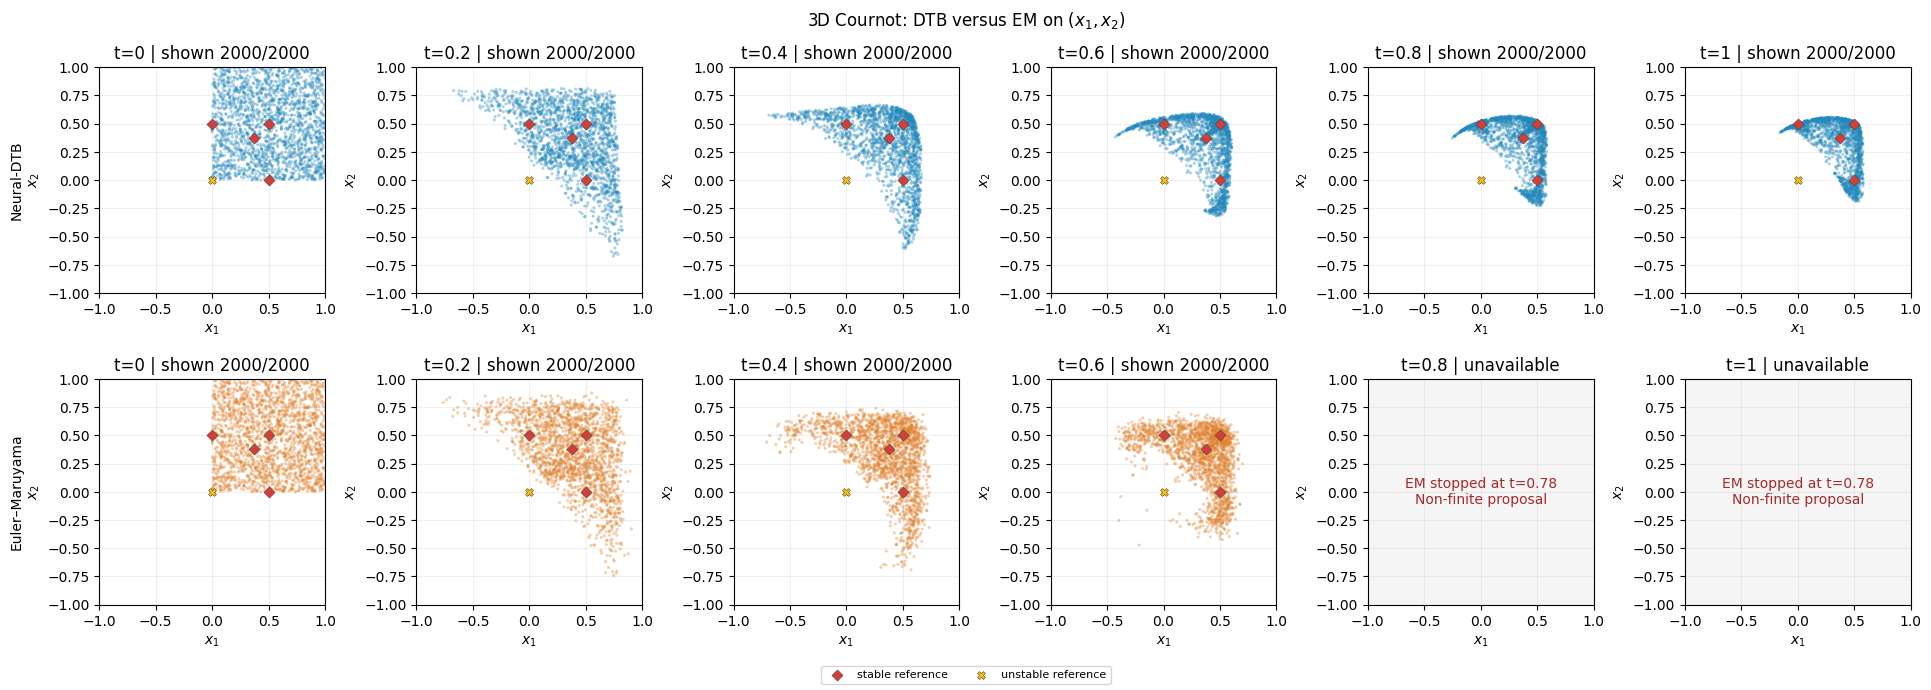

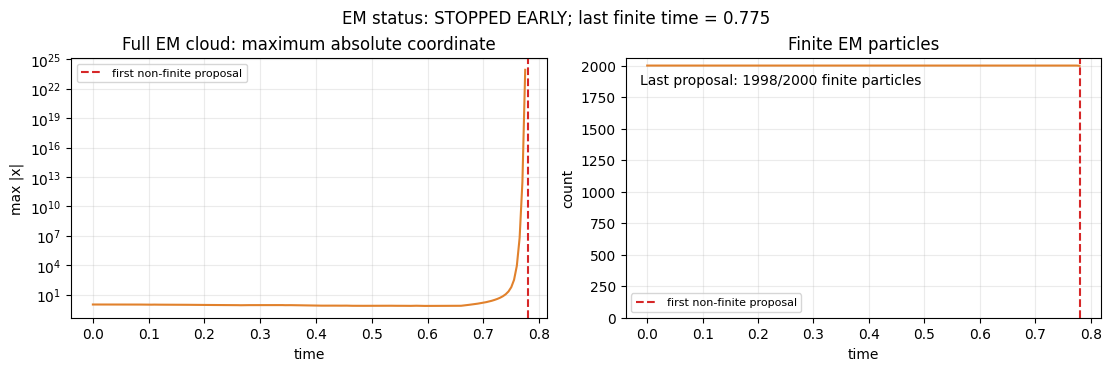

In [8]:
if not isinstance(dtb_history, np.ndarray) or dtb_history.ndim != 3:
    raise RuntimeError('Finish the DTB simulation in Block 3 before plotting the comparison.')
if not np.array_equal(dtb_history[0], em_history[0]):
    raise ValueError('Initial clouds differ. Rerun Blocks 2–7 with a single configuration.')
if not np.allclose(state_times[:len(em_times)], em_times):
    raise ValueError('Time grids differ. Rerun Blocks 2–7 with a single configuration.')
if COMPARISON_VIEW is not None:
    view = np.asarray(COMPARISON_VIEW, dtype=float)
    if view.shape != (2,) or not np.isfinite(view).all() or view[0] >= view[1]:
        raise ValueError('COMPARISON_VIEW must be None or (lower, upper) with lower < upper.')

comparison_figures = {}
comparison_references = KNOWN_EQUILIBRIA.detach().cpu().numpy()
for first, second in COORDINATE_PAIRS:
    if first == second or not (1 <= first <= DIM and 1 <= second <= DIM):
        raise ValueError('Coordinate pairs use distinct one-based indices.')
    a, b = first - 1, second - 1
    if COMPARISON_VIEW is None:
        available_em_steps = [step for step in snapshot_steps if step < len(em_times)]
        xlim = finite_plot_limits(np.concatenate((dtb_history[snapshot_steps, :, a].ravel(),
            em_history[available_em_steps, :, a].ravel(), comparison_references[:, a])))
        ylim = finite_plot_limits(np.concatenate((dtb_history[snapshot_steps, :, b].ravel(),
            em_history[available_em_steps, :, b].ravel(), comparison_references[:, b])))
    else:
        xlim = ylim = tuple(COMPARISON_VIEW)
    figure, axes = plt.subplots(2, len(snapshot_steps), squeeze=False,
        figsize=(3.2 * len(snapshot_steps), 6.8), constrained_layout=True)
    for row, (label, history, color) in enumerate([
        ('Neural-DTB', dtb_history, '#2389bd'), ('Euler–Maruyama', em_history, '#e1812c'),
    ]):
        for column, state_index in enumerate(snapshot_steps):
            axis = axes[row, column]
            requested_time = state_times[state_index]
            axis.set(xlim=xlim, ylim=ylim, xlabel=rf'$x_{{{first}}}$', ylabel=rf'$x_{{{second}}}$')
            axis.set_aspect('equal', adjustable='box')
            axis.grid(alpha=.2)
            if column == 0:
                axis.set_ylabel(label + '\n' + rf'$x_{{{second}}}$')
            if state_index >= len(history):
                axis.set_title(f't={requested_time:g} | unavailable')
                axis.set_facecolor('#f5f5f5')
                message = f'EM stopped at t={em_summary["failure_time"]:g}\nNon-finite proposal'
                axis.text(.5, .5, message, transform=axis.transAxes,
                    ha='center', va='center', color='#a52a2a', fontsize=10)
                continue
            points = history[state_index]
            visible = ((points[:, a] >= xlim[0]) & (points[:, a] <= xlim[1]) &
                       (points[:, b] >= ylim[0]) & (points[:, b] <= ylim[1]))
            axis.scatter(points[visible, a], points[visible, b], s=5, alpha=.38,
                color=color, edgecolors='none', rasterized=True)
            axis.set_title(f't={requested_time:g} | shown {int(visible.sum())}/{len(points)}')
            for mask, marker, ref_color, ref_label in [
                (STABLE_MASK, 'D', '#d43e38', 'stable reference'),
                (~STABLE_MASK, 'X', '#ffbf00', 'unstable reference'),
            ]:
                axis.scatter(comparison_references[mask, a], comparison_references[mask, b],
                    s=32, marker=marker, color=ref_color, edgecolors='#444444',
                    linewidths=.4, label=ref_label, zorder=4)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.legend(handles, labels, loc='outside lower center', ncol=2, fontsize=8)
    figure.suptitle(rf'3D Cournot: DTB versus EM on $(x_{{{first}}},x_{{{second}}})$')
    comparison_figures[(first, second)] = figure

em_record_times = np.asarray([item['time'] for item in em_records])
em_max_abs = np.asarray([item['max_abs'] for item in em_records])
em_finite_counts = np.asarray([item['finite_particles'] for item in em_records])
em_health_figure, health_axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
health_axes[0].semilogy(em_record_times, np.maximum(em_max_abs, 1e-30), color='#e1812c')
health_axes[0].set(title='Full EM cloud: maximum absolute coordinate', ylabel='max |x|')
health_axes[1].plot(em_record_times, em_finite_counts, color='#e1812c')
health_axes[1].set(title='Finite EM particles', ylabel='count', ylim=(0, N_PARTICLES * 1.03))
health_axes[1].text(.03, .9,
    f'Last proposal: {em_finite_counts[-1]}/{N_PARTICLES} finite particles',
    transform=health_axes[1].transAxes, fontsize=10)
for axis in health_axes:
    axis.set_xlabel('time')
    axis.grid(alpha=.25)
    if em_summary['failure_step'] is not None:
        axis.axvline(em_summary['failure_time'], color='tab:red', linestyle='--',
            label='first non-finite proposal')
        axis.legend(fontsize=8)
status_text = 'COMPLETED' if em_summary['completed'] else 'STOPPED EARLY'
em_health_figure.suptitle(f'EM status: {status_text}; last finite time = {em_times[-1]:g}')
plt.show()

## Block 8 — Optional comparison export

With `SAVE_RUN=True`, Block 4 saves the original DTB results. This block adds an
`em_comparison` subfolder containing matched figures, finite EM history, the
failed proposal when present, per-step health and timing CSV, and configuration.
EM and DTB times are stored separately so missing EM snapshots are explicit.

In [9]:
if SAVE_RUN:
    import csv
    import json

    if output_dir is None:
        raise RuntimeError('Run Block 4 with SAVE_RUN=True before exporting the comparison.')
    comparison_dir = output_dir / 'em_comparison'
    comparison_dir.mkdir(parents=True, exist_ok=True)
    comparison_config = {
        'dtb_config': CONFIG,
        'dtb_source_revision': '9792385a49a2c0edc8fd1567f7b1eb86928ab2a3',
        'dtb_source_sha256': '84e314e5f5ca4fe205547e9631259300973b642c5f9e122240aaa6e0e6bbdd89',
        'em': em_summary,
        'comparison_view': None if COMPARISON_VIEW is None else list(COMPARISON_VIEW),
    }
    (comparison_dir / 'configuration.json').write_text(
        json.dumps(comparison_config, indent=2, allow_nan=False) + '\n', encoding='utf-8')
    em_export_arrays = {
        'em_particles': em_history, 'em_times': em_times,
        'dtb_times': state_times, 'requested_snapshot_times': np.asarray(SNAPSHOT_TIMES),
    }
    if em_result['failure_proposal'] is not None:
        em_export_arrays['nonfinite_failure_proposal'] = em_result['failure_proposal']
    np.savez_compressed(comparison_dir / 'em_history.npz', **em_export_arrays)
    with (comparison_dir / 'em_diagnostics.csv').open('w', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(em_records[0]))
        writer.writeheader()
        writer.writerows(em_records)
    for (first, second), figure in comparison_figures.items():
        figure.savefig(comparison_dir / f'dtb_vs_em_x{first}_x{second}.png', dpi=180, bbox_inches='tight')
    em_health_figure.savefig(comparison_dir / 'em_health.png', dpi=180, bbox_inches='tight')
    print('Saved comparison:', comparison_dir)
else:
    print('SAVE_RUN=False: comparison displayed without saving files.')

SAVE_RUN=False: comparison displayed without saving files.
